In [1]:
import pandas as pd
import sqlite3

In [2]:
conn = sqlite3.connect('inventory.db')

In [3]:
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", conn)
tables

,name
0,gold
1,silver
2,oil


In [4]:
for table in tables['name']:
    print('-'*50, f'{table}', '-'*50)
    print('Counts of records: ', pd.read_sql_query(f"SELECT COUNT(*) as count FROM {table}", conn)['count'].values[0])
    display(pd.read_sql_query(f"SELECT * FROM {table} LIMIT 5", conn))

-------------------------------------------------- gold --------------------------------------------------
Counts of records:  6432


,Date,Close,High,Low,Open,Volume
0,2000-08-30 00:00:00.000000,273.899994,273.899994,273.899994,273.899994,0
1,2000-08-31 00:00:00.000000,278.299988,278.299988,274.799988,274.799988,0
2,2000-09-01 00:00:00.000000,277.000000,277.000000,277.000000,277.000000,0
3,2000-09-05 00:00:00.000000,275.799988,275.799988,275.799988,275.799988,2
4,2000-09-06 00:00:00.000000,274.200012,274.200012,274.200012,274.200012,0


-------------------------------------------------- silver --------------------------------------------------
Counts of records:  6434


,Date,Close,High,Low,Open,Volume
0,2000-08-30 00:00:00.000000,4.930,4.950,4.895,4.950,2319
1,2000-08-31 00:00:00.000000,5.003,5.045,4.920,4.920,1612
2,2000-09-01 00:00:00.000000,5.004,5.035,4.985,5.035,1375
3,2000-09-05 00:00:00.000000,4.998,5.005,4.975,4.990,856
4,2000-09-06 00:00:00.000000,4.983,5.000,4.980,5.000,232


-------------------------------------------------- oil --------------------------------------------------
Counts of records:  6441


,Date,Close,High,Low,Open,Volume
0,2000-08-23 00:00:00.000000,32.049999,32.799999,31.950001,31.950001,79385
1,2000-08-24 00:00:00.000000,31.629999,32.240002,31.400000,31.900000,72978
2,2000-08-25 00:00:00.000000,32.049999,32.099998,31.320000,31.700001,44601
3,2000-08-28 00:00:00.000000,32.869999,32.919998,31.860001,32.040001,46770
4,2000-08-29 00:00:00.000000,32.720001,33.029999,32.560001,32.820000,49131


In [5]:
gold = pd.read_sql_query("SELECT *FROM gold", conn)
silver = pd.read_sql_query("SELECT *FROM silver", conn)
oil = pd.read_sql_query("SELECT * FROM oil", conn)

In [6]:
gold["Date"] = pd.to_datetime(gold["Date"]).dt.date
silver["Date"] = pd.to_datetime(silver["Date"]).dt.date
oil["Date"] = pd.to_datetime(oil["Date"]).dt.date

In [7]:
gold.set_index("Date", inplace=True)

In [8]:
silver.set_index("Date", inplace=True)
oil.set_index("Date", inplace=True)

In [9]:
gold.tail()

,Close,High,Low,Open,Volume
Date,,,,,
2026-04-14,4825.000000,4841.600098,4770.100098,4770.100098,288
2026-04-15,4800.000000,4843.600098,4798.000000,4843.600098,182
2026-04-16,4785.399902,4810.899902,4785.399902,4810.899902,805
2026-04-17,4857.600098,4879.700195,4767.200195,4771.600098,805
2026-04-20,4832.799805,4847.299805,4752.000000,4811.799805,87061


In [10]:
gold = pd.DataFrame(gold)

In [11]:
gold.dtypes

Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

In [21]:
gold.info()
gold.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 6432 entries, 2000-08-30 to 2026-04-20
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   6432 non-null   float64
 1   High    6432 non-null   float64
 2   Low     6432 non-null   float64
 3   Open    6432 non-null   float64
 4   Volume  6432 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 559.5+ KB


,Close,High,Low,Open,Volume
count,6432.000000,6432.000000,6432.000000,6432.000000,6432.000000
mean,1292.994371,1299.983551,1285.710588,1292.976975,4288.179260
std,820.643715,826.987558,813.970895,820.656573,24028.431961
min,255.100006,256.100006,255.000000,255.000000,0.000000
25%,653.074982,655.975006,650.925003,652.900024,23.000000
50%,1252.699951,1257.900024,1247.500000,1253.099976,118.500000
75%,1704.100006,1712.724976,1692.149994,1704.299957,455.000000
max,5318.399902,5586.200195,5301.600098,5415.700195,386334.000000


In [22]:
silver.info()
silver.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 6434 entries, 2000-08-30 to 2026-04-20
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   6434 non-null   float64
 1   High    6434 non-null   float64
 2   Low     6434 non-null   float64
 3   Open    6434 non-null   float64
 4   Volume  6434 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 559.6+ KB


,Close,High,Low,Open,Volume
count,6434.000000,6434.000000,6434.000000,6434.000000,6434.000000
mean,18.697890,18.857959,18.542862,18.708366,1451.550668
std,11.844957,12.104997,11.620424,11.881869,8404.892833
min,4.026000,4.026000,4.026000,4.026000,0.000000
25%,12.262500,12.325000,12.191250,12.270000,5.000000
50%,17.045000,17.116500,16.954000,17.030001,38.000000
75%,23.771000,23.926250,23.600750,23.754749,148.750000
max,115.080002,121.300003,112.735001,116.889999,170297.000000


In [23]:
oil.info()
oil.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 6441 entries, 2000-08-23 to 2026-04-20
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   6441 non-null   float64
 1   High    6441 non-null   float64
 2   Low     6441 non-null   float64
 3   Open    6441 non-null   float64
 4   Volume  6441 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 560.0+ KB


,Close,High,Low,Open,Volume
count,6441.000000,6441.000000,6441.000000,6441.000000,6.441000e+03
mean,64.806732,65.831992,63.732323,64.818724,3.036013e+05
std,24.548354,24.827825,24.231712,24.544428,2.076166e+05
min,-37.630001,13.690000,-40.320000,-14.000000,0.000000e+00
25%,46.540001,47.470001,45.619999,46.570000,1.227410e+05
50%,63.830002,64.750000,62.950001,63.840000,2.760950e+05
75%,82.150002,83.209999,80.879997,82.089996,3.921390e+05
max,145.289993,147.270004,143.220001,145.190002,2.288230e+06


In [31]:
for i in [gold, silver, oil]:
    print(i.isnull().sum())

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


# First exploring gold stock

In [35]:
import matplotlib.pyplot as plt
%matplotlib inline

<Axes: title={'center': 'Gold high'}, xlabel='Date'>

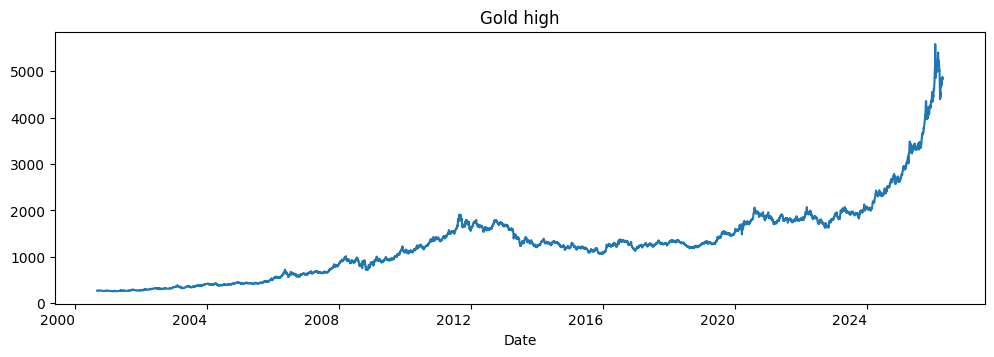

In [41]:
figure, axis = plt.subplots()
figure.autofmt_xdate()
gold['High'].plot(figsize=(12,4), title="Gold high", )

In [42]:
from datetime import datetime

In [44]:
datetime.now()

datetime.datetime(2026, 4, 23, 23, 6, 45, 296085)

In [53]:
#Change datatype of index from object to datetime
gold.index = pd.to_datetime(gold.index)

In [54]:
gold.index

DatetimeIndex(['2000-08-30', '2000-08-31', '2000-09-01', '2000-09-05',
               '2000-09-06', '2000-09-07', '2000-09-08', '2000-09-11',
               '2000-09-12', '2000-09-13',
               ...
               '2026-04-07', '2026-04-08', '2026-04-09', '2026-04-10',
               '2026-04-13', '2026-04-14', '2026-04-15', '2026-04-16',
               '2026-04-17', '2026-04-20'],
              dtype='datetime64[ns]', name='Date', length=6432, freq=None)

In [57]:
gold.resample(rule='YE').max()

,Close,High,Low,Open,Volume
Date,,,,,
2000-12-31,278.399994,278.399994,278.399994,278.399994,28696
2001-12-31,293.299988,294.000000,293.299988,293.500000,28775
2002-12-31,349.200012,350.500000,347.200012,350.399994,50896
2003-12-31,416.899994,417.200012,417.200012,416.899994,77377
2004-12-31,456.000000,456.500000,451.500000,454.399994,110725
2005-12-31,528.400024,538.500000,526.500000,528.400024,109050
2006-12-31,719.799988,723.000000,723.000000,723.000000,82649
2007-12-31,839.599976,843.200012,843.200012,843.200012,165342
2008-12-31,1003.200012,1014.599976,996.400024,1005.000000,158862


<Axes: xlabel='Date'>

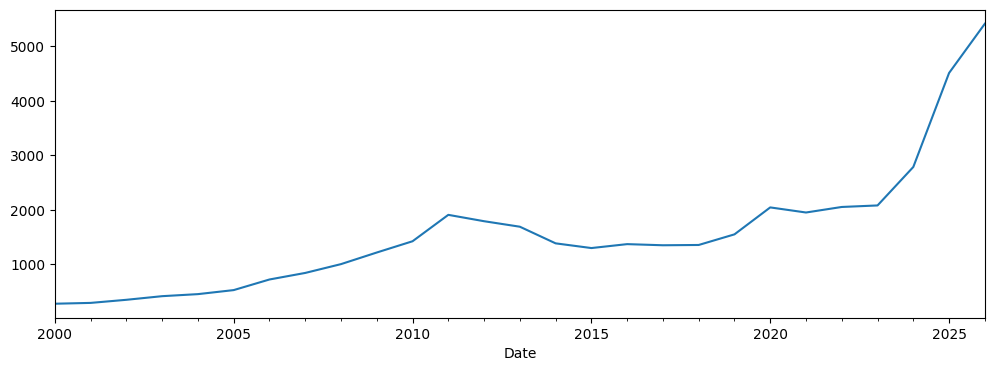

In [72]:
gold.resample(rule='YE').max()['Open'].plot(figsize=(12,4))

<Axes: xlabel='Date'>

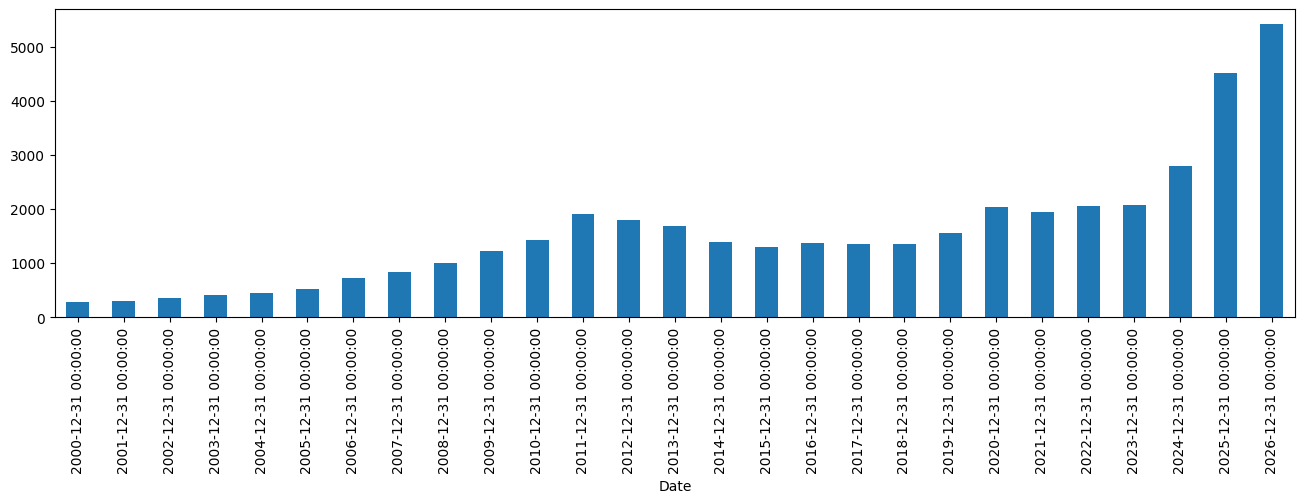

In [80]:
gold.resample(rule='YE').max()['Open'].plot(xlim=['2020-01-01', '2026-03-31'], kind='bar', figsize=(16,4))